# Unsupervised Learning

## What is unsupervised learning?
In **unsupervised learning**, we do **not** have labels (no target `y`).
The algorithm tries to discover patterns from the input features `X` only.

Common unsupervised tasks:

- **Clustering:** group similar points (K-Means, DBSCAN)
- **Dimensionality reduction:** reduce features (PCA)

In clustering, the output is a **cluster label** for each point (0, 1, 2, …), but these are **not true class labels**.

---

# K-Means Clustering

## What K-Means does
K-Means groups data into **K clusters** by finding **K centroids**.

### Algorithm steps
1) Choose K centroids (initially random)
2) Assign each point to the closest centroid (by distance)
3) Update each centroid to the **mean** of its assigned points
4) Repeat until centroids stop changing much

### What K-Means minimizes (inertia / SSE)
K-Means tries to minimize:

- **SSE / inertia** = sum of squared distances from each point to its cluster centroid.

Lower inertia usually means tighter clusters, but inertia always decreases when K increases.

### Hyperparameters (important ones)
- `n_clusters` (K): number of clusters  
- `init`: how centroids start (`"k-means++"` is default and good)
- `n_init`: how many times to run K-Means with different starts  
  - higher values → more stable results
- `max_iter`: maximum iterations per run

### How to choose K
- **Elbow method:** plot K vs inertia, look for a bend (“elbow”)
- **Silhouette score:** measures compactness + separation  
  - range is about [-1, 1], higher is better  
  - works best when clusters are well-separated

---

# DBSCAN Clustering

## What DBSCAN does
DBSCAN = **Density-Based Spatial Clustering of Applications with Noise**

DBSCAN forms clusters as **dense regions**:
- Points in dense areas become clusters
- Points in sparse areas become **noise/outliers** (label = -1)
- DBSCAN does **NOT** need K

---

## Key concepts (very important)
### 1) eps (ε-neighborhood)
`eps` defines a radius around a point.
Two points are “neighbors” if they are within distance `eps`.

### 2) min_samples
`min_samples` is the minimum number of points required in an eps-neighborhood
to consider a region “dense”.

### 3) Core / Border / Noise points
- **Core point:** has at least `min_samples` points in its eps neighborhood  
- **Border point:** not dense enough to be core, but close to a core point  
- **Noise point:** not close to any core point (cluster label = -1)

---

## DBSCAN Hyperparameters
### `eps` (most important)
- Too small `eps` → many points become noise, clusters break apart
- Too large `eps` → clusters merge into one big cluster

### `min_samples`
- Larger `min_samples` → stricter definition of dense region  
  (more noise, fewer clusters)
- Smaller `min_samples` → easier to form clusters  
  (less noise, more clusters, possibly messy clusters)

---

## How to choose `min_samples` (simple rule)
A common rule:
- `min_samples ≈ 2 * number_of_features`
Example:
- If data has 2 features → min_samples ≈ 4
- If data has 10 features → min_samples ≈ 20

For teaching in 2D datasets, `min_samples = 4` or `5` is common.

---

## How to choose `eps` (practical method)
### K-distance graph method (most common)
1) Choose `min_samples`
2) Compute distance to each point’s **k-th nearest neighbor** (k = min_samples)
3) Sort these distances
4) Plot them and look for an “elbow”
5) Choose `eps` around that elbow

This gives a data-driven estimate of eps instead of guessing.

---

# How do we evaluate clustering performance?

In clustering (K-Means, DBSCAN), we usually **don’t have true labels**. So we can’t use classification metrics like accuracy, precision, recall, or F1-score. Instead, we evaluate clustering by checking whether clusters are **tight**, **separated**, and **stable**.

---

# 1) Internal evaluation (no labels needed)

## Compactness (within-cluster quality)
A good cluster should contain points that are close to each other.

- **K-Means Inertia / SSE**: sum of squared distances from points to their centroid  
- Lower inertia → tighter clusters  
- But inertia always decreases when K increases, so it’s mainly used to choose K (elbow method)

## Separation (between-cluster quality)
Different clusters should be far apart and not heavily overlapping.

- If clusters overlap a lot, the clustering is not very useful
- We want clear gaps between clusters

## Silhouette idea (compactness + separation together)
Silhouette compares:
- distance of a point to its **own cluster**
- vs distance to the **nearest other cluster**

Interpretation:
- **High** silhouette → compact and well-separated clusters  
- **Around 0** → overlapping clusters  
- **Negative** → many points may be in the wrong cluster  

---

# 2) Stability evaluation (practical check)

Even without labels, good clustering should be **stable**.

- If you rerun K-Means with different random starts, results should not change too much  
- Use higher `n_init` to reduce randomness in K-Means  
- For DBSCAN, small parameter changes should not completely destroy cluster structure

---

# 3) DBSCAN-specific performance checks

DBSCAN can label points as **noise** (outliers), so we also look at:

- **Number of clusters found**
- **Percentage of noise points** (label = -1)

Parameter effects:
- `eps` too small → many noise points, clusters break into pieces  
- `eps` too large → clusters merge into one big cluster  
- `min_samples` too large → stricter density, more noise  
- `min_samples` too small → clusters may become messy

---

# 4) External evaluation (only if true labels exist)

If you have ground-truth labels (only for evaluation), you can compare clusters to real labels using:

- **ARI (Adjusted Rand Index)**
- **NMI (Normalized Mutual Information)**

These are not always available in real unsupervised problems, but they are useful for benchmarking on labeled datasets.

## Summary: When to use what?
### Use K-Means when:
- clusters are round/spherical
- you roughly know K
- speed matters

### Use DBSCAN when:
- cluster shapes are weird/non-spherical
- you want outlier detection (noise points)
- you do not know K

# Kmeans

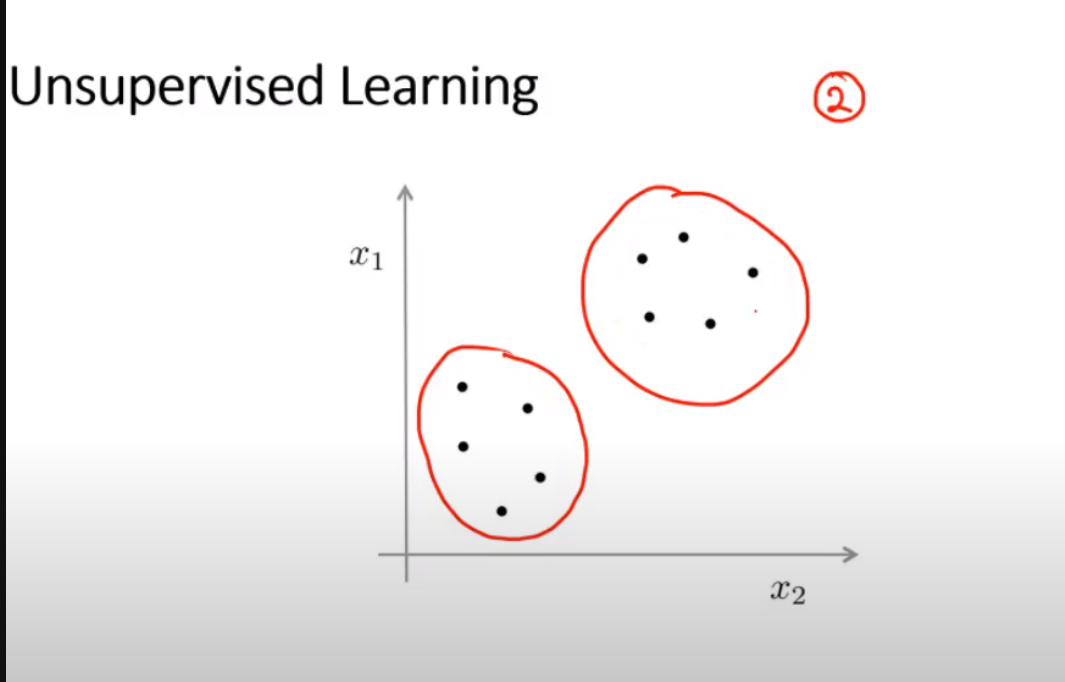

In [16]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt


In [17]:
df = pd.read_csv('income.csv')
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


Text(0, 0.5, 'Income')

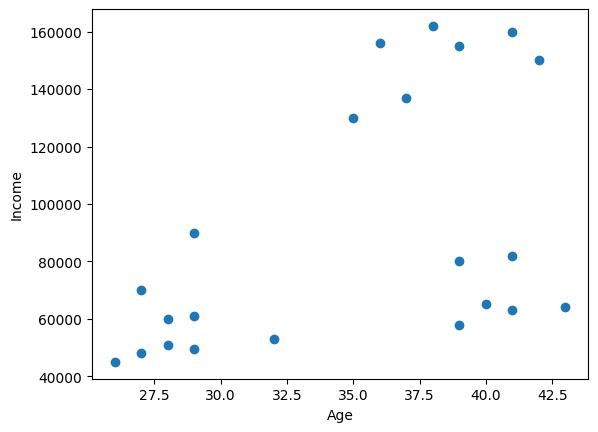

In [18]:
plt.scatter(df.Age, df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')

In [19]:
km = KMeans(n_clusters=3)
km.fit(df.drop('Name', axis=1).values)

KMeans(n_clusters=3)

In [20]:
y_pred = km.predict(df.drop('Name', axis=1).values)

In [21]:
y_pred = km.fit_predict(df.drop('Name', axis=1).values)
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [22]:
df['cluster'] = y_pred
df

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,2


In [23]:
km.cluster_centers_

array([[3.32000000e+01, 6.26333333e+04],
       [3.92000000e+01, 1.56600000e+05],
       [3.60000000e+01, 1.33500000e+05]])

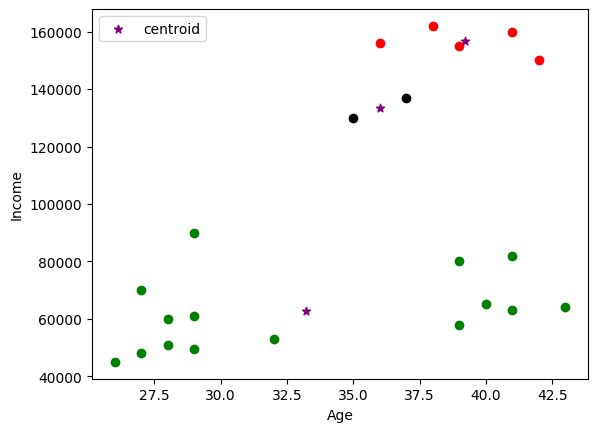

In [24]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel("Age")
plt.ylabel('Income')
plt.legend()

In [25]:
sse = []
k_range = range(1,10)
for k in k_range:
  km = KMeans(n_clusters=k)
  km.fit(df.drop('Name', axis=1).values)
  sse.append(km.inertia_)

sse

[39748148467.86364,
 3318233942.5904756,
 1606229739.1071424,
 814746044.2545456,
 296500418.0952381,
 238167028.08333337,
 186466998.4619048,
 120800257.03333335,
 132666791.33333333]

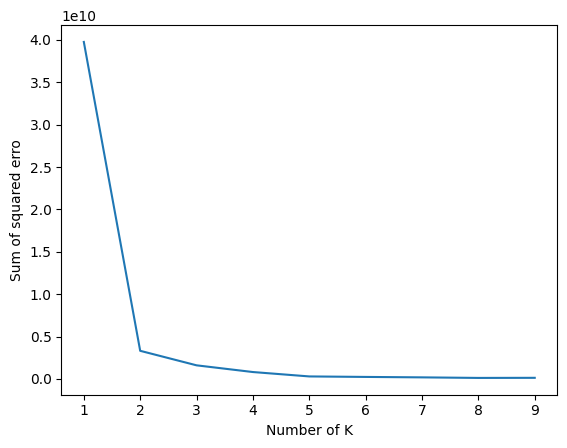

In [26]:
plt.xlabel('Number of K')
plt.ylabel('Sum of squared erro')
plt.plot(k_range, sse)

# DBSCAN

In [27]:
df = pd.read_csv('./pedestrian-crashes-chapel-hill-region-original.csv')
df.head()

,city,county,crashday,crashhour,crashloc,crashmonth,crashsevr,crashtype,development,drvrinjury,latitude,longitude,pedinjury,pedpos,rdclass,rdconfig,drvragegrp
0,Fayetteville,Cumberland,Tuesday,8,Non-Roadway,January,A: Suspected Serious Injury,Backing Vehicle - Parking Lot,Commercial,O: No Injury,35.076330,-78.966100,A: Suspected Serious Injury,Non-Roadway - Parking Lot / Other,Public Vehicular Area,Two-Way: Not Divided,50-59
1,Graham,Alamance,Saturday,15,Non-Intersection,September,A: Suspected Serious Injury,Backing Vehicle - Driveway / Sidewalk Intersec...,Residential,O: No Injury,36.073750,-79.390200,A: Suspected Serious Injury,Sidewalk / Shared Use Path / Driveway Crossing,NC Route,Two-Way: Not Divided,40-49
2,None - Rural Crash,Craven,Wednesday,19,Non-Intersection,December,K: Killed,Walking Along Roadway Against Traffic - From B...,Residential,Unknown Injury,35.337681,-77.156394,K: Killed,Travel Lane,State Secondary Route,Two-Way: Not Divided,25-29
3,None - Rural Crash,Forsyth,Saturday,20,Non-Intersection,December,C: Possible Injury,Motorist Right Turn - Perpendicular Paths,Residential,Unknown Injury,36.069341,-80.290345,C: Possible Injury,Travel Lane,Local Street,Two-Way: Not Divided,Unknown
4,Cary,Wake,Saturday,19,Non-Roadway,November,A: Suspected Serious Injury,Off Roadway - Parking Lot,Commercial,O: No Injury,35.758158,-78.734982,A: Suspected Serious Injury,Non-Roadway - Parking Lot / Other,Public Vehicular Area,Two-Way: Not Divided,0-19


In [28]:
df = df[df['crashday']!='.']
df = df[df['crashloc']!='Unknown']

lati = df['latitude']
long = df['longitude']


In [29]:
from folium import plugins
import folium


world_map = folium.Map(location=[34.63932, -77.9439],zoom_start=7)

incidents = plugins.MarkerCluster().add_to(world_map)

# loop through the dataframe and add each data point to the mark cluster
for lat, lng, crashtype,crashloc, in zip(lati, long, df.crashtype, df.crashloc):
    folium.Marker(
        location=[lat, lng],
        icon=None,
        popup=(lat, lng, crashtype, crashloc),
    ).add_to(incidents)

# display map
#world_map

In [31]:
#world_map.save('./Initial Visualization.html')